# Correlation on Episode Outcomes

In [132]:
import json
import pandas as pd
import plotly.express as px
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [133]:
def plot_correlation(correlation, runid, ax):
    # Create a heatmap of the correlation matrix with annotations
    mask = np.tril(np.ones_like(correlation, dtype=bool))
    sns.heatmap(
        correlation,
        mask=mask,
        annot=True,
        fmt=".4f",
        cmap="bwr",
        cbar=True,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        linecolor="black",
        ax=ax,
    )
    # plt.title(f"Spearman Correlation Matrix for {runid}")

File: data/lifting_trials_k1b5sgl8_lhs_1000_rl_model_38997816_steps.txt
Average Success Rate: 0.924
Average Tip Rate: 0.029
Average Slip Rate: 0.047
Sanity Check: 1.0



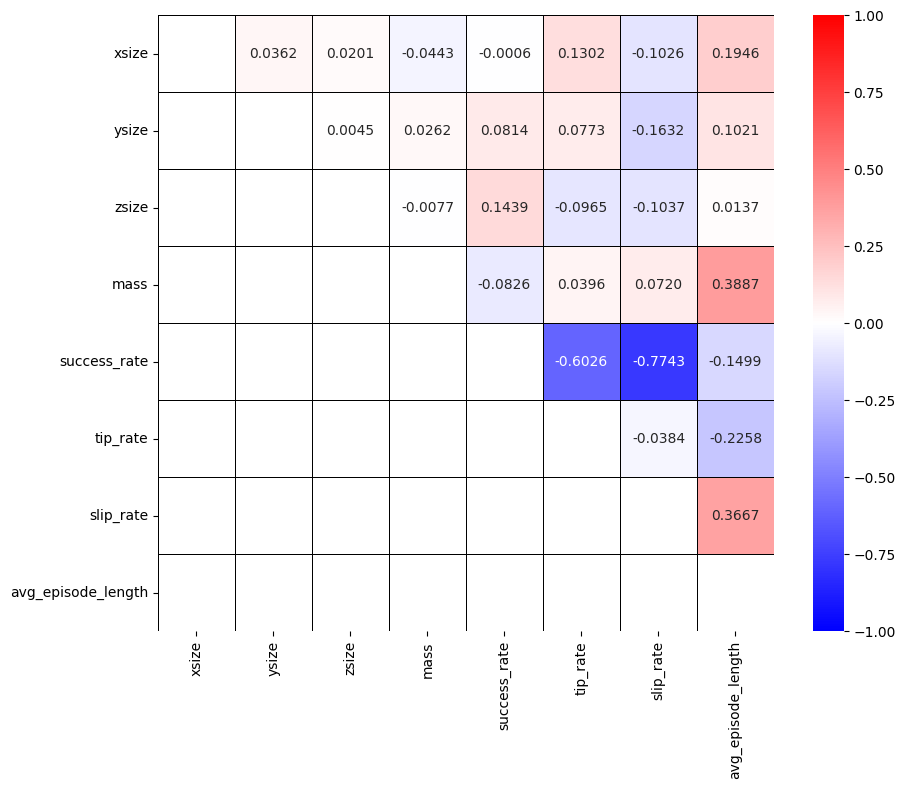

File: data/lifting_trials_jckeurhl_lhs_1000_rl_model_20000000_steps.txt
Average Success Rate: 0.981
Average Tip Rate: 0.01
Average Slip Rate: 0.009
Sanity Check: 1.0



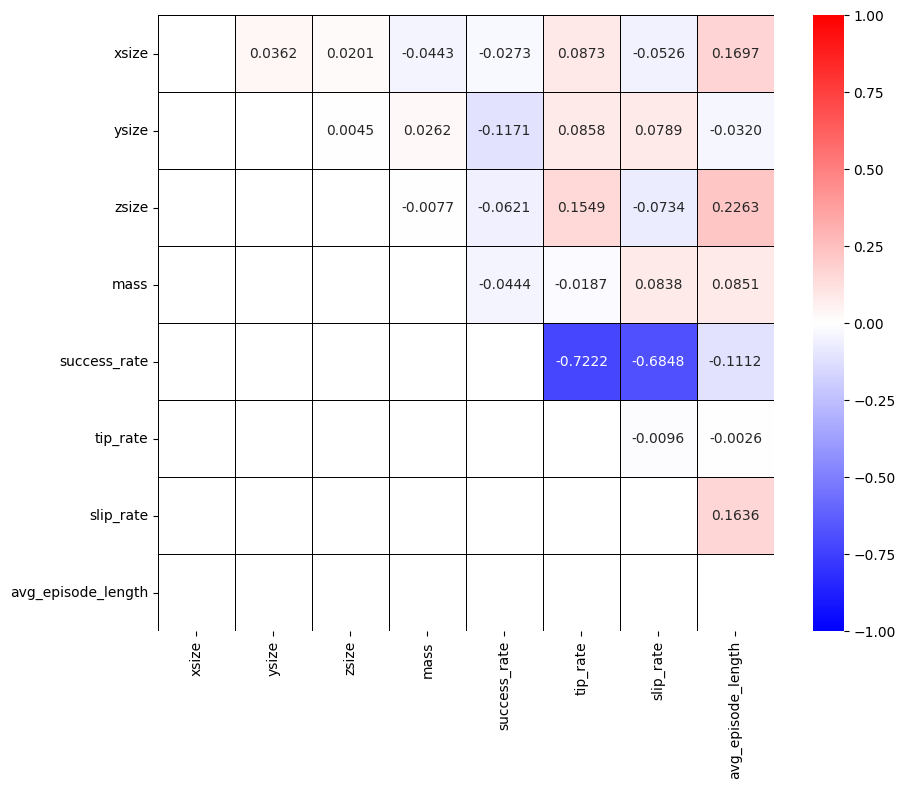

File: data/lifting_trials_jckeurhl_lhs_1000_rl_model_10000000_steps.txt
Average Success Rate: 0.97
Average Tip Rate: 0.017
Average Slip Rate: 0.013
Sanity Check: 1.0



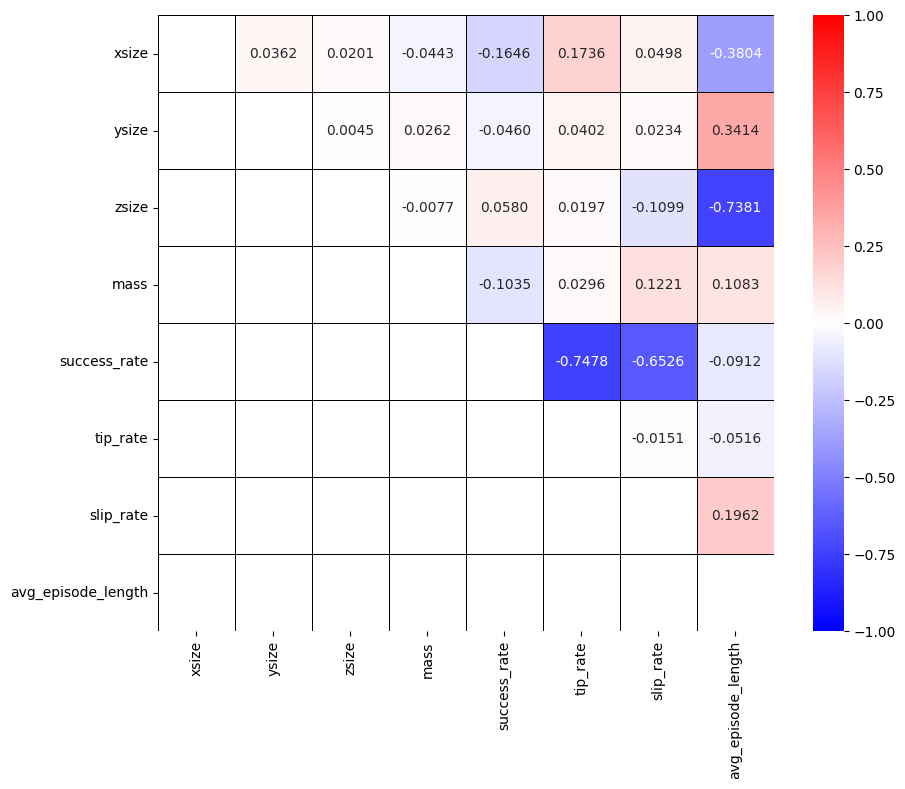

File: data/lifting_trials_27vo09mu_lhs_1000_rl_model_20000000_steps.txt
Average Success Rate: 0.947
Average Tip Rate: 0.018
Average Slip Rate: 0.035
Sanity Check: 1.0



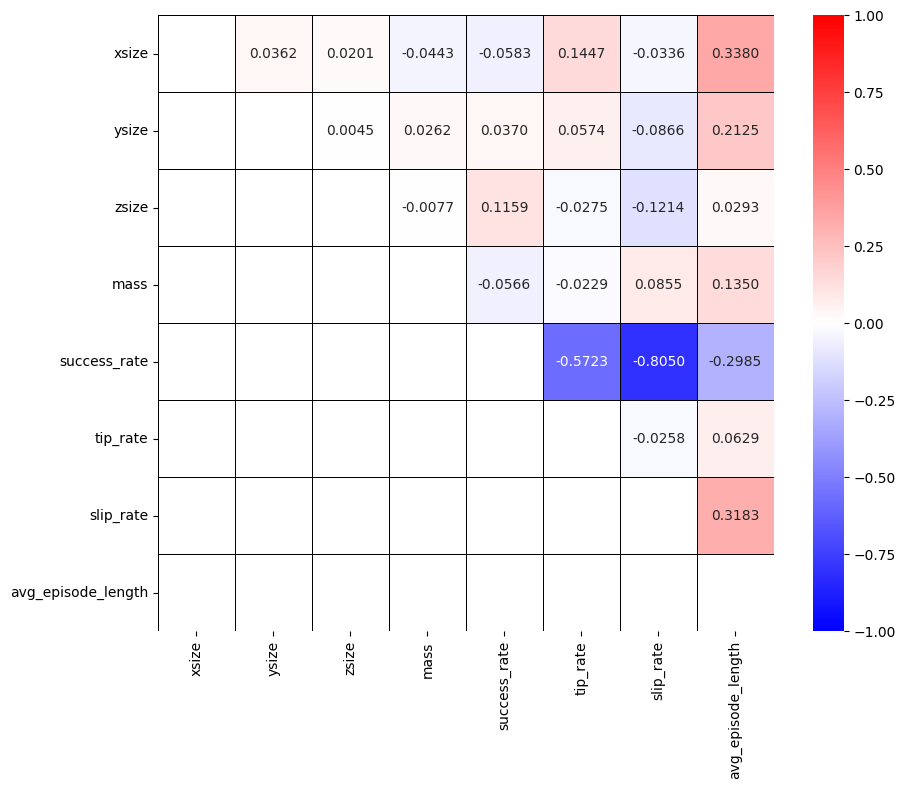

File: data/lifting_trials_baseline_lhs_1000_None.txt
Average Success Rate: 0.876
Average Tip Rate: 0.054
Average Slip Rate: 0.07
Sanity Check: 1.0



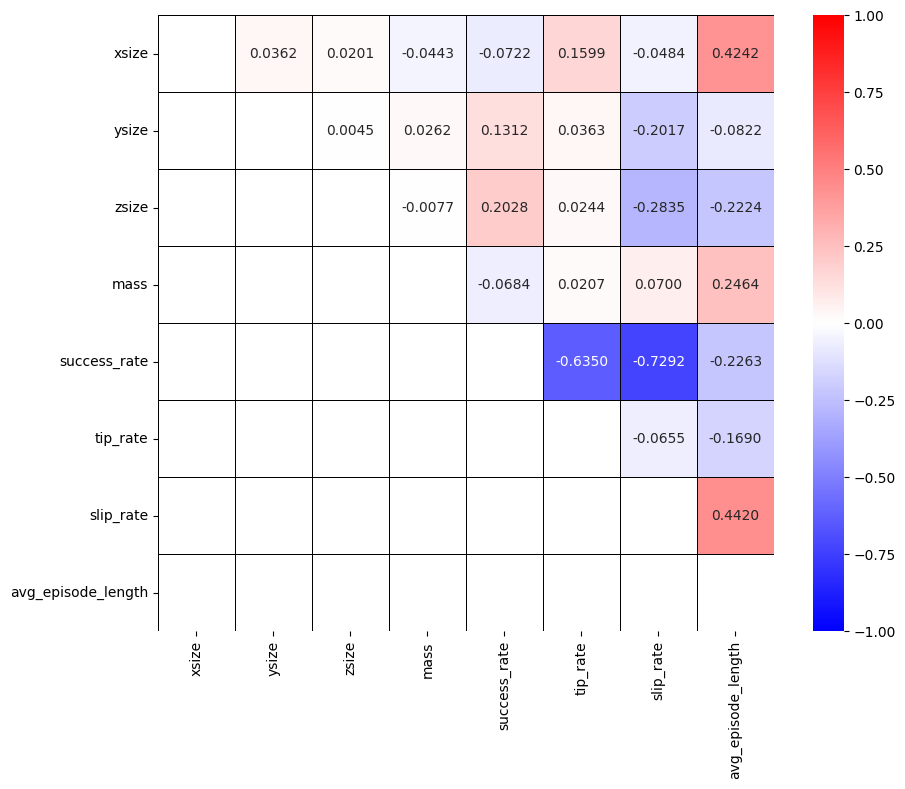

In [134]:
data_files = glob.glob("data/*.txt")
for file_path in data_files:
    # Initialize variables to store the total success rate and the number of trials
    successes = 0
    tips = 0
    slips = 0
    num_trials = 0
    data = []

    # Read the JSON data from the file
    with open(file_path, "r") as f:
        for line in f:
            trial_data = json.loads(line)
            successes += trial_data["success_rate"]
            tips += trial_data["tip_rate"]
            slips += trial_data["slip_rate"]
            num_trials += 1
            data.append(trial_data)

    # Calculate the average success rate
    average_success_rate = successes / num_trials if num_trials > 0 else 0
    average_tip_rate = tips / num_trials if num_trials > 0 else 0
    average_slip_rate = slips / num_trials if num_trials > 0 else 0

    # Print rates
    print(f"File: {file_path}")
    print(f"Average Success Rate: {average_success_rate}")
    print(f"Average Tip Rate: {average_tip_rate}")
    print(f"Average Slip Rate: {average_slip_rate}")
    print(
        f"Sanity Check: {average_tip_rate + average_slip_rate + average_success_rate}\n"
    )

    #perform correlation analysis on over all trials against sizes and mass
    data = pd.DataFrame(data)

    correlation_matrix = data.corr("spearman")
    #spearman b/c it doesn't assume linear relationships, only monotonic ones
    #1 means Perfect monotonic increasing relationship (as one variable increases, the other always increases).

    fig, ax = plt.subplots(figsize=(10, 8))
    plot_correlation(correlation_matrix, os.path.basename(file_path), ax)
    plt.savefig(
        f"data/correlation_matrix_{os.path.basename(file_path).replace('.txt', '')}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show(block=False)


# Training Metrics Plots


Download the trainin metrics from here: https://byu.app.box.com/folder/318139468144?s=wnyacqotrch9af543xw8rxz3eg45gok0

Place training_data.zip in this directory and unzip it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np

In [3]:
#unzip training_metrics.zip
import zipfile
import os
with zipfile.ZipFile("training_metrics.zip", "r") as zip_ref:
    zip_ref.extractall(".")

#remove the zip file
os.remove("training_metrics.zip")

In [4]:
eval_success_files = glob.glob("training_metrics/eval/success_rate.csv")
print(f"Evaluation Success Rate Files: \n{eval_success_files}\n")

eval_ep_len_files = glob.glob("training_metrics/eval/ep_len_mean.csv")
print(f"Evaluation Episode Length Files: \n{eval_ep_len_files}\n")

eval_ep_rew_files = glob.glob("training_metrics/eval/mean_reward.csv")
print(f"Evaluation Episode Reward Files: \n{eval_ep_rew_files}\n")

rollout_success_files = glob.glob(
    "training_metrics/rollout/success_rate.csv")
print(f"Rollout Success Rate Files: \n{rollout_success_files}\n")

rollout_ep_len_files = glob.glob(
    "training_metrics/rollout/ep_len_mean.csv")
print(f"Rollout Episode Length Files: \n{rollout_ep_len_files}\n")

rollout_ep_rew_files = glob.glob(
    "training_metrics/rollout/mean_reward.csv")
print(f"Rollout Episode Reward Files: \n{rollout_ep_rew_files}\n")

Evaluation Success Rate Files: 
['training_metrics/eval/success_rate.csv']

Evaluation Episode Length Files: 
['training_metrics/eval/ep_len_mean.csv']

Evaluation Episode Reward Files: 
['training_metrics/eval/mean_reward.csv']

Rollout Success Rate Files: 
['training_metrics/rollout/success_rate.csv']

Rollout Episode Length Files: 
['training_metrics/rollout/ep_len_mean.csv']

Rollout Episode Reward Files: 
['training_metrics/rollout/mean_reward.csv']



In [5]:
def read_csvs(files: list):
    data_frames = []
    for file in files:
        data = pd.read_csv(file)
        data_frames.append(data)

    return data_frames[0]


eval_success_data = read_csvs(eval_success_files)
eval_ep_rew_data = read_csvs(eval_ep_rew_files)
eval_ep_len_data = read_csvs(eval_ep_len_files)

rollout_success_data = read_csvs(rollout_success_files)
rollout_ep_len_data = read_csvs(rollout_ep_len_files)
rollout_ep_rew_data = read_csvs(rollout_ep_rew_files)

In [6]:
eval_success_data.head()

,global_step,cool-silence-750 - eval/success_rate,morning-sound-749 - eval/success_rate,devout-terrain-748 - eval/success_rate,rich-field-747 - eval/success_rate,flowing-glitter-746 - eval/success_rate,smooth-flower-745 - eval/success_rate,flowing-feather-744 - eval/success_rate,efficient-flower-743 - eval/success_rate,desert-pine-742 - eval/success_rate,lucky-silence-739 - eval/success_rate
0,499994,NaN,0.0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0
1,499996,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN
2,999988,NaN,0.0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0
3,999992,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN
4,1499982,NaN,0.0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0


In [7]:
rollout_success_data.head()

,global_step,cool-silence-750 - rollout/success_rate,morning-sound-749 - rollout/success_rate,devout-terrain-748 - rollout/success_rate,rich-field-747 - rollout/success_rate,flowing-glitter-746 - rollout/success_rate,smooth-flower-745 - rollout/success_rate,flowing-feather-744 - rollout/success_rate,efficient-flower-743 - rollout/success_rate,desert-pine-742 - rollout/success_rate,lucky-silence-739 - rollout/success_rate
0,114688,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN
1,180224,NaN,0.0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0
2,229376,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN
3,344064,0.0,NaN,NaN,0.0,NaN,0.0,NaN,0.0,NaN,NaN
4,360448,NaN,0.0,0.0,NaN,0.0,NaN,0.0,NaN,0.0,0.0


In [8]:
# Assuming `data` is your DataFrame and the first column is the reference
def reinterpolate_data(data, step=100000):
    # Define the new range for interpolation
    new_x = np.arange(data.iloc[:, 0].min(), data.iloc[:, 0].max(), step)

    # Create a new DataFrame for the interpolated data
    interpolated_data = pd.DataFrame({"interp_global_step": new_x})

    
    # Interpolate each column based on the first column
    for col in data.columns[1:]:
        # make new data frame with first column and col
        data_subset = data[[data.columns[0], col]]

        #remove rows with NaN values
        data_subset = data_subset.dropna()

        # Interpolate the data
        interpolated_col = np.interp(new_x, data_subset.iloc[:, 0], data_subset[col])

        # Add the interpolated column to the new DataFrame
        interpolated_data[col] = interpolated_col

        
    
    return interpolated_data

# Reinterpolate the data

eval_success_data_interp = reinterpolate_data(eval_success_data)
eval_ep_rew_data_interp = reinterpolate_data(eval_ep_rew_data)
eval_ep_len_data_interp = reinterpolate_data(eval_ep_len_data)

rollout_success_data_interp = reinterpolate_data(rollout_success_data)
rollout_ep_len_data_interp = reinterpolate_data(rollout_ep_len_data)
rollout_ep_rew_data_interp = reinterpolate_data(rollout_ep_rew_data)

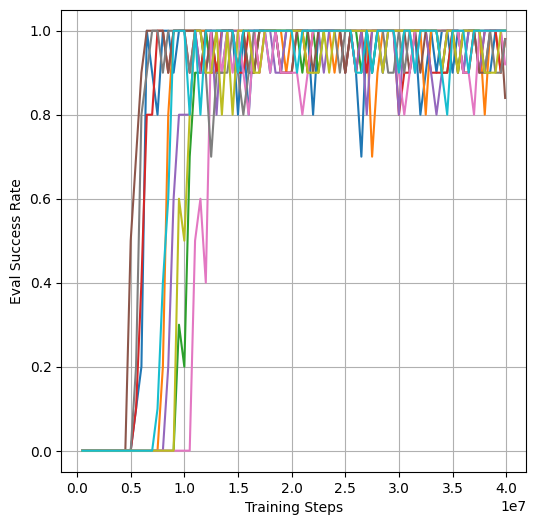

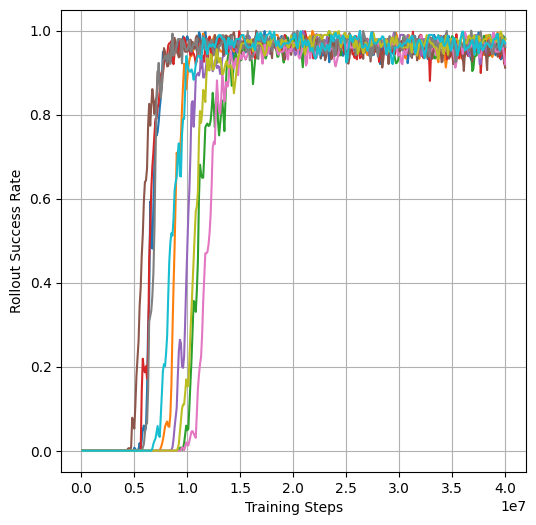

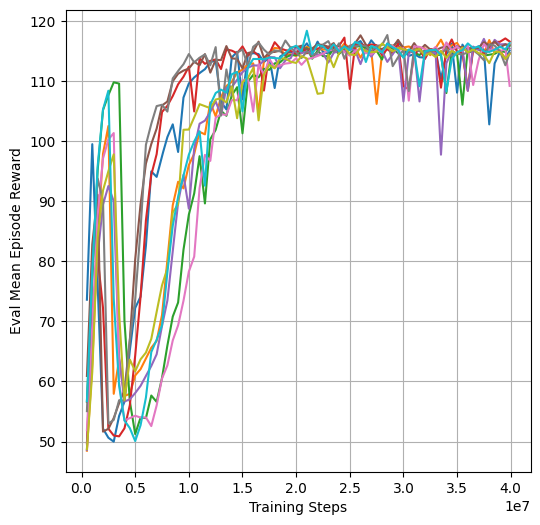

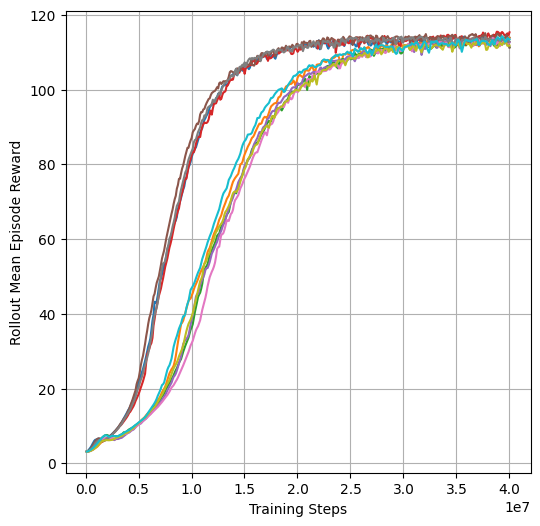

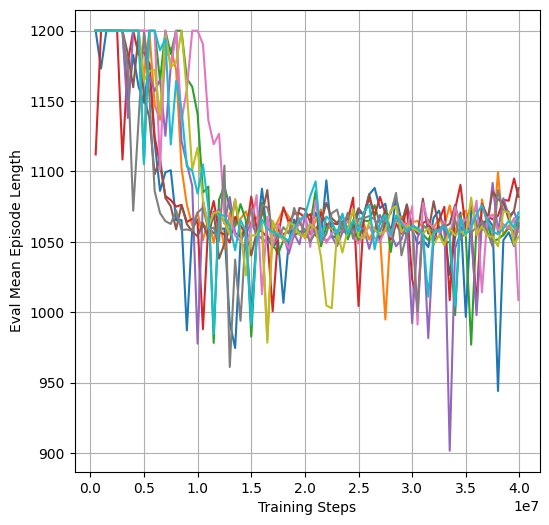

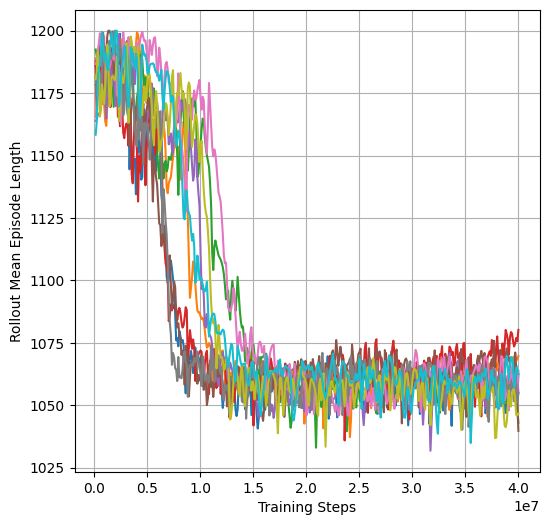

In [9]:
def plot_raw_data(ax, data, col_name="success_rate"):
    #plot the data line onto the given figure
    success_rate_columns = [col for col in data.columns if col_name in col]
    for col in success_rate_columns:
        ax.plot(data.iloc[:,0], data[col], label= f"{col}")


fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, eval_success_data_interp, "success_rate")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Eval Success Rate")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, rollout_success_data_interp, "success_rate")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Rollout Success Rate")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, eval_ep_rew_data_interp, "mean_reward")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Eval Mean Episode Reward")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, rollout_ep_rew_data_interp, "ep_rew_mean")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Rollout Mean Episode Reward")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, eval_ep_len_data_interp, "mean_ep_length")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Eval Mean Episode Length")

fig, ax = plt.subplots(figsize=(6, 6))
plot_raw_data(ax, rollout_ep_len_data_interp, "ep_len_mean")
plt.grid()
plt.xlabel("Training Steps")
plt.ylabel("Rollout Mean Episode Length")


plt.show()

In [10]:
eval_success_data_interp.tail()

,interp_global_step,cool-silence-750 - eval/success_rate,morning-sound-749 - eval/success_rate,devout-terrain-748 - eval/success_rate,rich-field-747 - eval/success_rate,flowing-glitter-746 - eval/success_rate,smooth-flower-745 - eval/success_rate,flowing-feather-744 - eval/success_rate,efficient-flower-743 - eval/success_rate,desert-pine-742 - eval/success_rate,lucky-silence-739 - eval/success_rate
390,39499994,1.0,0.900094,1.0,0.900062,1.0,0.999876,0.999906,0.900062,1.0,1.0
391,39599994,1.0,0.920094,1.0,0.920062,1.0,0.959876,0.979906,0.920062,1.0,1.0
392,39699994,1.0,0.940094,1.0,0.940062,1.0,0.919875,0.959906,0.940062,1.0,1.0
393,39799994,1.0,0.960094,1.0,0.960062,1.0,0.879875,0.939906,0.960062,1.0,1.0
394,39899994,1.0,0.980095,1.0,0.980063,1.0,0.839875,0.919905,0.980063,1.0,1.0


In [11]:
#now I need to get mean and std over each column in each data set

def get_mean_and_minmax(data):
    #get the mean and min/max of each column at each time step, excluding the first column
    run_data = data.iloc[:, 1:]  # Exclude the first column
    mean = run_data.mean(axis=1)
    min = run_data.min(axis=1)
    max = run_data.max(axis=1)


    # new data frame with the first column and the mean and std
    new_data = pd.DataFrame({
        "global_step": data.iloc[:, 0],
        "mean": mean,
        "min": min,
        "max": max
    })

    return new_data

eval_success_data_mean_minmax = get_mean_and_minmax(eval_success_data_interp)
eval_ep_rew_data_mean_minmax = get_mean_and_minmax(eval_ep_rew_data_interp)
eval_ep_len_data_mean_minmax = get_mean_and_minmax(eval_ep_len_data_interp)

rollout_success_data_mean_minmax = get_mean_and_minmax(rollout_success_data_interp)
rollout_ep_len_data_mean_minmax = get_mean_and_minmax(rollout_ep_len_data_interp)
rollout_ep_rew_data_mean_minmax = get_mean_and_minmax(rollout_ep_rew_data_interp)

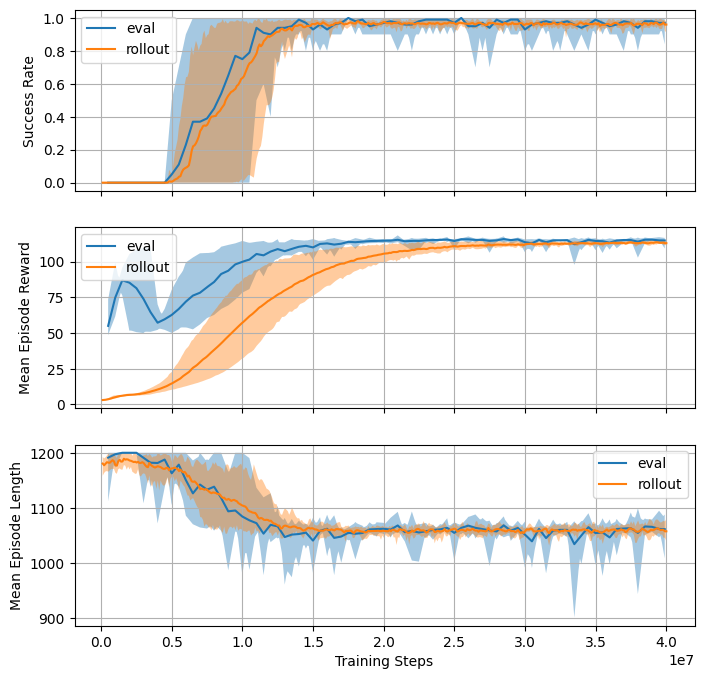

In [23]:
def plot_mean_and_std(ax, data, label=""):
    #plot mean as a line and 3*std as a shaded area
    ax.plot(data["global_step"], data["mean"], label=label)
    ax.fill_between(
        data["global_step"],
        data["min"],
        data["max"],
        alpha=0.4,
    )
    ax.legend()
    ax.grid(True)


fig, ax = plt.subplots(3,1, figsize=(8, 8), sharex=True)
plot_mean_and_std(ax[0], eval_success_data_mean_minmax, label="eval")
plot_mean_and_std(ax[0], rollout_success_data_mean_minmax, label="rollout")
ax[0].set_ylabel("Success Rate")


plot_mean_and_std(ax[1], eval_ep_rew_data_mean_minmax, label="eval")
plot_mean_and_std(ax[1], rollout_ep_rew_data_mean_minmax, label="rollout")
ax[1].set_ylabel("Mean Episode Reward")


plot_mean_and_std(ax[2], eval_ep_len_data_mean_minmax, label="eval")
plot_mean_and_std(ax[2], rollout_ep_len_data_mean_minmax, label="rollout")
ax[2].set_ylabel("Mean Episode Length")
ax[2].set_xlabel("Training Steps")
plt.savefig(
    "data/training_metrics_minmax.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [24]:
def get_mean_and_std(data):
    #get the mean and std of each column at each time step, excluding the first column
    run_data = data.iloc[:, 1:]  # Exclude the first column
    mean = run_data.mean(axis=1)
    std = run_data.std(axis=1)

    # new data frame with the first column and the mean and std
    new_data = pd.DataFrame({
        "global_step": data.iloc[:, 0],
        "mean": mean,
        "std": std
    })

    return new_data

eval_success_data_mean_std = get_mean_and_std(eval_success_data_interp)
eval_ep_rew_data_mean_std = get_mean_and_std(eval_ep_rew_data_interp)
eval_ep_len_data_mean_std = get_mean_and_std(eval_ep_len_data_interp)

rollout_success_data_mean_std = get_mean_and_std(rollout_success_data_interp)
rollout_ep_len_data_mean_std = get_mean_and_std(rollout_ep_len_data_interp)
rollout_ep_rew_data_mean_std = get_mean_and_std(rollout_ep_rew_data_interp)

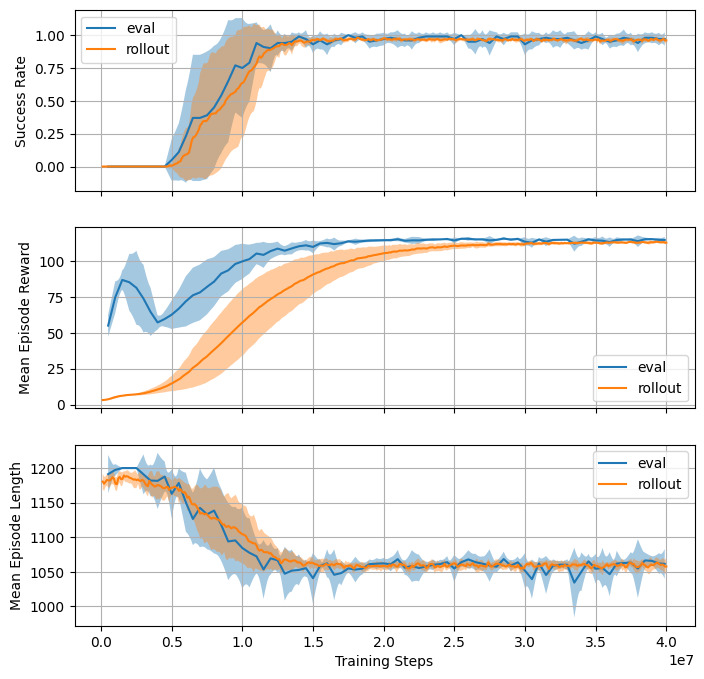

In [27]:
def plot_mean_and_Nstd(ax, data, label="", N=3):
    #plot mean as a line and N*std as a shaded area
    ax.plot(data["global_step"], data["mean"], label=label)
    ax.fill_between(
        data["global_step"],
        data["mean"] - N * data["std"],
        data["mean"] + N * data["std"],
        alpha=0.4,
    )
    ax.legend()
    ax.grid(True)

fig, ax = plt.subplots(3,1, figsize=(8, 8), sharex=True)
N = 1
plot_mean_and_Nstd(ax[0], eval_success_data_mean_std, label="eval", N=N)
plot_mean_and_Nstd(ax[0], rollout_success_data_mean_std, label="rollout", N=N)
ax[0].set_ylabel("Success Rate")

plot_mean_and_Nstd(ax[1], eval_ep_rew_data_mean_std, label="eval", N=N)
plot_mean_and_Nstd(ax[1], rollout_ep_rew_data_mean_std, label="rollout", N=N)
ax[1].set_ylabel("Mean Episode Reward")

plot_mean_and_Nstd(ax[2], eval_ep_len_data_mean_std, label="eval", N=N)
plot_mean_and_Nstd(ax[2], rollout_ep_len_data_mean_std, label="rollout", N=N)
ax[2].set_ylabel("Mean Episode Length")
ax[2].set_xlabel("Training Steps")
plt.savefig(
    "data/training_metrics_mean_std.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()